# **Data Exploration**

This notebook begins the data exploration phase of the HDFS_v1 anomaly detection study.

The purpose of this notebook is to understand the structure of the dataset before building any rule-based or machine learning models. This includes reviewing dataset dimensions, examining anomaly labels, exploring event definitions, analyzing sequences of system log events, and identifying the primary data sources that will be used during experimentation.

The dataset originates from the **Hadoop Distributed File System (HDFS)**, a distributed storage system designed to store and process large volumes of data across multiple machines. As HDFS processes data, it generates system log messages that record the actions being performed throughout the environment.

Large files in HDFS are divided into smaller units called **blocks**. As each block moves through the system, HDFS records a sequence of log events describing what occurred during processing. These events may include activities such as receiving a block, verifying a block, writing data, replicating data, or handling errors.

In this dataset, the original log messages have been converted into event identifiers such as **E1, E2, E3, and E4**, where each identifier represents a specific log template. The ordered collection of events associated with a single block is referred to as a **trace**.

A trace can be viewed as the complete processing history of a block. Rather than analyzing individual log messages in isolation, this study focuses on the sequence of events that occurred while processing a block. The central question is whether patterns within these event sequences can be used to distinguish normal system behavior from anomalous system behavior.

In other words, the objective is to determine whether rule-based methods and machine learning models can examine a block's history of system log events and correctly identify whether that block represents:

* **Normal behavior**
* **Anomalous behavior**

The primary files reviewed in this notebook are:

* `anomaly_label.csv`
* `HDFS.log_templates.csv`
* `Event_traces.csv`
* `Event_occurrence_matrix.csv`

These files are explored in a logical progression. The anomaly labels provide the ground-truth classifications, the log templates define the meaning of each event identifier, the event traces capture the ordered sequence of system log events associated with each block, and the occurrence matrix provides a numerical representation of event activity suitable for machine learning.

Additional files included in the dataset archive are:

* `HDFS.log`
* `HDFS.npz`

These files are reviewed for completeness and reproducibility purposes but are not expected to be used directly in model development.

The main goal of this exploration is to understand what information is available, identify potential predictive features, detect any data quality concerns, and prepare the dataset for rule-based detection and machine learning experimentation.


In [20]:
# Import standard libraries used for data exploration

from pathlib import Path

import pandas as pd
import numpy as np

# Set pandas display options so previews are easier to read in the notebook
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)

# Define the project root folder.
# Since this notebook is inside the notebooks folder, Path.cwd() may point to the project root
# or to the notebooks folder depending on how VS Code launches it.
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

# Define data folder paths
data_dir = project_root / "data"
raw_dir = data_dir / "raw"
processed_dir = data_dir / "processed"

print("Current path:", current_path)
print("Project root:", project_root)
print("Raw data folder:", raw_dir)
print("Processed data folder:", processed_dir)

Current path: c:\Users\taman\Documents\hdfs-anomaly-detection-study\notebooks
Project root: c:\Users\taman\Documents\hdfs-anomaly-detection-study
Raw data folder: c:\Users\taman\Documents\hdfs-anomaly-detection-study\data\raw
Processed data folder: c:\Users\taman\Documents\hdfs-anomaly-detection-study\data\processed


#### **Dataset Acquisition**

The HDFS_v1 dataset used in this study is maintained through a public archival mirror hosted on Kaggle. The archive preserves the original dataset files, source references, licensing information, and citation requirements to support reproducibility.

The dataset contains both raw HDFS log data and several processed files that have been prepared for anomaly detection research. These processed files provide multiple representations of the same underlying system behavior, ranging from raw event sequences to machine learning ready feature matrices.

The dataset archive contains the following files:

* `anomaly_label.csv` – Ground truth labels identifying each HDFS block as Normal or Anomaly.
* `HDFS.log_templates.csv` – Definitions of the event identifiers (E1–E29) used throughout the dataset.
* `Event_traces.csv` – Sequential event traces associated with each HDFS block.
* `Event_occurrence_matrix.csv` – Numerical event occurrence counts suitable for machine learning models.
* `HDFS.log` – Original raw HDFS system logs used to generate the processed datasets.
* `HDFS.npz` – Compressed binary representation of the dataset.

The archive is downloaded directly from Kaggle using KaggleHub, allowing the dataset to be reproduced automatically without storing large data files in the GitHub repository.


In [21]:
# Download the HDFS_v1 dataset archive from Kaggle

import kagglehub

dataset_path = Path(
    kagglehub.dataset_download(
        "tamaniwilliams/hdfs-v1-loghub-dataset-archive"
    )
)

print("Dataset location:")
print(dataset_path)

Dataset location:
C:\Users\taman\.cache\kagglehub\datasets\tamaniwilliams\hdfs-v1-loghub-dataset-archive\versions\1


In [22]:
# Display files contained in the dataset archive

for file in dataset_path.rglob("*"):
    print(file.name)

anomaly_label.csv
Event_occurrence_matrix.csv
Event_traces.csv
HDFS.log
HDFS.log_templates.csv
HDFS.npz


#### **Dataset Download Verification**

The HDFS_v1 dataset archive was successfully downloaded and extracted using the `kagglehub` package.

Dataset Source:

https://www.kaggle.com/datasets/tamaniwilliams/hdfs-v1-loghub-dataset-archive

Inspection of the downloaded archive confirmed that all expected dataset files were available for analysis. This verification step ensures that future researchers can reproduce the data acquisition process and obtain the same dataset version used throughout this study.

## ***Anomaly Label Dataset Overview***

The anomaly_label.csv file contains the ground-truth classification for each HDFS block trace.

Each record consists of:

- BlockId: Unique identifier for an HDFS block trace.
- Label: Classification of the trace as either Normal or Anomaly.

These labels will serve as the target variable during model evaluation and will be used to measure classification performance using Accuracy, Precision, Recall, and F1 Score.

In [23]:
# Load anomaly labels

labels_df = pd.read_csv(
    dataset_path / "anomaly_label.csv"
)

labels_df.head()



,BlockId,Label
0,blk_-1608999687919862906,Normal
1,blk_7503483334202473044,Normal
2,blk_-3544583377289625738,Anomaly
3,blk_-9073992586687739851,Normal
4,blk_7854771516489510256,Normal


**Dataset Dimensions**

In [24]:
print(f"Rows: {len(labels_df):,}")
print(f"Columns: {len(labels_df.columns)}")

Rows: 575,061
Columns: 2


**Dataset Schema**

In [25]:
labels_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 575061 entries, 0 to 575060
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   BlockId  575061 non-null  str  
 1   Label    575061 non-null  str  
dtypes: str(2)
memory usage: 8.8 MB


**Label Column Distribution**

In [26]:
label_counts = labels_df["Label"].value_counts()
label_pct = labels_df["Label"].value_counts(normalize=True) * 100

for label in label_counts.index:
    print(
        f"{label}: "
        f"{label_counts[label]:,} "
        f"({label_pct[label]:.2f}%)"
    )

Normal: 558,223 (97.07%)
Anomaly: 16,838 (2.93%)


**Block ID Column Validation**

In [27]:
unique_blocks = labels_df["BlockId"].nunique()
total_rows = len(labels_df)

print(f"Rows: {total_rows:,}")
print(f"Unique Block IDs: {unique_blocks:,}")

if unique_blocks == total_rows:
    print("Validation Passed: Each record contains a unique Block ID.")
else:
    print("Validation Failed: Duplicate Block IDs were detected.")

Rows: 575,061
Unique Block IDs: 575,061
Validation Passed: Each record contains a unique Block ID.


### Initial Observations

The dataset contains 575,061 blocks of labeled HDFS traces.

Of these, 558,223 (97.07%) are labeled as Normal and 16,838 (2.93%) are labeled as Anomaly.

This indicates a significant class imbalance, which is common in anomaly detection problems where abnormal events occur much less frequently than normal system behavior.

The number of unique Block IDs matches the total number of records in the dataset (575,061). This confirms that each HDFS block trace is represented by a single record and has exactly one associated ground-truth label.

## ***HDFS Log Template Dataset Overview***

The HDFS.log_templates.csv file provides the mapping between event identifiers and their corresponding log message templates.

During preprocessing, raw HDFS log messages were grouped into event templates and assigned identifiers such as E1, E2, E3, and E4. These identifiers are referenced throughout the Event_traces.csv dataset.

Understanding these template definitions is important because the event sequences used for anomaly detection are composed entirely of these event identifiers. This file allows the meaning of each event within a trace to be interpreted.

In [28]:
# Load log templates

templates_df = pd.read_csv(
    dataset_path / "HDFS.log_templates.csv"
)

templates_df.head()

,EventId,EventTemplate
0,E1,[*]Adding an already existing block[*]
1,E2,[*]Verification succeeded for[*]
2,E3,[*]Served block[*]to[*]
3,E4,[*]Got exception while serving[*]to[*]
4,E5,[*]Receiving block[*]src:[*]dest:[*]


**Dataset Dimensions**

In [29]:
print(f"Rows: {len(templates_df):,}")
print(f"Columns: {len(templates_df.columns)}")

Rows: 29
Columns: 2


**Dataset Schema**

In [30]:
templates_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   EventId        29 non-null     str  
 1   EventTemplate  29 non-null     str  
dtypes: str(2)
memory usage: 596.0 bytes


**Complete List of Template Column Definitions**

In [31]:
pd.set_option("display.max_rows", None)

templates_df

,EventId,EventTemplate
0,E1,[*]Adding an already existing block[*]
1,E2,[*]Verification succeeded for[*]
2,E3,[*]Served block[*]to[*]
3,E4,[*]Got exception while serving[*]to[*]
4,E5,[*]Receiving block[*]src:[*]dest:[*]
5,E6,[*]Received block[*]src:[*]dest:[*]of size[*]
6,E7,[*]writeBlock[*]received exception[*]
7,E8,[*]PacketResponder[*]for block[*]Interrupted[*]
8,E9,[*]Received block[*]of size[*]from[*]
9,E10,[*]PacketResponder[*]Exception[*]


### **Initial Observations**

The HDFS.log_templates.csv dataset contains 29 unique event templates that represent common operations and system events within the Hadoop Distributed File System.

Many templates describe normal block processing activities, including receiving blocks, transferring blocks between nodes, allocating storage, replicating data, and deleting blocks. Other templates describe exceptions, interruptions, replication issues, and failed transfer operations.

The event templates serve as the vocabulary used throughout the Event_traces.csv dataset. Each event identifier (E1 through E29) corresponds to a specific system action that may occur while a block is being processed.

Several templates appear to be associated with block replication and storage management, suggesting that replication behavior plays an important role in the overall lifecycle of an HDFS block. In addition, multiple templates reference exceptions and transfer failures, which may be useful indicators of anomalous system behavior.

Understanding these template definitions is important because anomaly detection will ultimately be performed on sequences of these event identifiers rather than on the original raw log messages.

## ***Event Trace Dataset Overview***

The Event_traces.csv file contains the sequence of events associated with each HDFS block trace. Each trace represents the ordered events that occurred during processing of a specific HDFS block.

These traces provide the behavioral information used to determine whether a block is normal or anomalous and will serve as a primary source of information for feature engineering and model development.

In [32]:
# Load event traces

traces_df = pd.read_csv(
    dataset_path / "Event_traces.csv"
)

traces_df.head()

,BlockId,Label,Type,Features,TimeInterval,Latency
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583


**Dataset Dimensions**

In [33]:
print(f"Rows: {len(traces_df):,}")
print(f"Columns: {len(traces_df.columns)}")

Rows: 575,061
Columns: 6


**Dataset Schema**

In [34]:
traces_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 575061 entries, 0 to 575060
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   BlockId       575061 non-null  str    
 1   Label         575061 non-null  str    
 2   Type          16838 non-null   float64
 3   Features      575061 non-null  str    
 4   TimeInterval  575061 non-null  str    
 5   Latency       575061 non-null  int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 26.3 MB


### Initial Observations

The Event_traces.csv dataset contains 575,061 traces and six columns.

Each record represents the processing history of a single HDFS block. The dataset combines ground-truth labels with behavioral information describing the sequence of system events that occurred while the block was being processed.

Unlike the anomaly_label.csv dataset, which only provides classifications, this dataset contains the event sequences that will ultimately be used to identify anomalous behavior.

The Features column contains ordered sequences of EventIds (E1 through E29). Based on the previously explored HDFS.log_templates.csv file, these EventIds correspond to specific HDFS operations such as receiving blocks, transferring blocks, allocating storage, deleting blocks, and handling exceptions.

The TimeInterval and Latency columns provide additional timing-related information that may help distinguish normal processing behavior from anomalous processing behavior.

An interesting observation from the dataset schema is that the Type column contains only 16,838 non-null values, whereas all other columns are fully populated. This suggests that the Type field may only be relevant for a subset of traces and warrants further investigation.

Because this dataset combines event sequences, timing information, and ground-truth labels, it serves as the primary source for feature engineering, model training, and model evaluation throughout this study.

**Record Validation**

Before exploring the event sequence information, it is important to verify that each record represents a unique HDFS block.

Because anomaly labels are assigned at the block level, each BlockId should appear only once within the dataset. Confirming this relationship ensures that each block has a single corresponding event sequence and ground-truth classification.

In [35]:
# Verify that every block appears only once in the dataset

print(f"Unique Block IDs: {traces_df['BlockId'].nunique():,}")

Unique Block IDs: 575,061


The number of unique Block IDs matches the total number of records in the dataset (575,061). This confirms that each HDFS block is represented by a single record and has exactly one associated event sequence and label.

**Missing Value Analysis**

Before selecting features for model development, it is important to identify any missing values.

During inspection of the dataset schema, the Type column was observed to contain substantially fewer non-null values than the other fields. The following analysis investigates the extent of missing data and whether a meaningful pattern exists.

In [36]:
# Count missing values in each column

traces_df.isnull().sum()

BlockId              0
Label                0
Type            558223
Features             0
TimeInterval         0
Latency              0
dtype: int64

In [37]:
traces_df.groupby("Label")["Type"].count()

Label
Fail       16838
Success        0
Name: Type, dtype: int64

**Type Column Analysis**

An interesting pattern emerged during exploration of the Type column. The number of missing values (558,223) was identical to the number of successful traces observed earlier in the dataset.

Further investigation confirmed that Type values are populated only for traces labeled as failures (anomalies). All successful traces contain null values for this field, while every anomalous trace contains a corresponding anomaly type.

This indicates that the Type column functions as anomaly-specific metadata rather than information available during normal system operation.

Because anomaly type information is only known after an anomaly has already occurred, using this field as a predictive feature would introduce target leakage. As a result, the Type column will not be used as an input feature during model development.

In [38]:
traces_df["Type"].value_counts().sort_index()

Type
0.0     2809
1.0      953
3.0     2950
4.0     1240
5.0     4167
7.0      476
8.0       45
9.0       34
10.0       3
11.0       3
12.0     130
13.0      10
16.0      22
17.0       3
18.0       9
19.0       8
20.0       7
21.0     724
22.0       9
23.0       1
24.0       3
25.0       2
27.0       3
28.0       1
30.0       1
31.0    3225
Name: count, dtype: int64

In [39]:
print(f"Unique anomaly types: {traces_df['Type'].nunique()}")

Unique anomaly types: 26


**Event Sequence Inspection**

The Features column contains the ordered sequence of EventIds associated with each HDFS block trace. Each EventId corresponds to a specific log template previously defined in the HDFS.log_templates.csv dataset.

These event sequences represent the chronological history of system activity that occurred while a block was being processed.

Understanding the structure, composition, and length of these sequences is important because they will serve as a primary source of information for feature engineering and model development.

The following analysis examines the format and characteristics of individual event traces.

In [40]:
# Display a complete event sequence

sample_trace = traces_df["Features"].iloc[0]

print(sample_trace)

[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26,E6,E5,E16,E6,E5,E18,E25,E26,E26,E3,E25,E6,E6,E5,E5,E16,E18,E26,E26,E5,E6,E5,E16,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E18,E25,E6,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E26,E26,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E25,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E18,E6,E5,E3,E3,E3,E3,E3,E16,E3,E3,E3,E3,E26,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E3,E23,E23,E23,E23,E23,E23,E23,E23,E23,E23,E21,E21,E21,E21,E21,E21,E21,E21,E21,E21]


In [41]:
# Split the sequence into individual events and count

events = sample_trace.strip("[]").split(",")

print(f"Events in sample trace: {len(events):,}")

Events in sample trace: 269


In [42]:
# Display the first 20 events in the sequence

events[:20]

['E5',
 'E22',
 'E5',
 'E5',
 'E11',
 'E11',
 'E9',
 'E9',
 'E11',
 'E9',
 'E26',
 'E26',
 'E26',
 'E6',
 'E5',
 'E16',
 'E6',
 'E5',
 'E18',
 'E25']

In [43]:
# Display the last 20 events in the sequence

events[-20:]

['E23',
 'E23',
 'E23',
 'E23',
 'E23',
 'E23',
 'E23',
 'E23',
 'E23',
 'E23',
 'E21',
 'E21',
 'E21',
 'E21',
 'E21',
 'E21',
 'E21',
 'E21',
 'E21',
 'E21']

**Event Sequence Observations**

Inspection of a sample trace revealed that the Features column contains an ordered sequence of event template identifiers, such as E5, E22, and E11. Each sequence represents the progression of system log events associated with a single HDFS block.

The sample trace contained 269 events, showing that individual block histories can be long and may capture extensive system activity. Repeated event identifiers were observed throughout the sequence, which suggests that certain system operations may occur multiple times during processing.

Because the event identifiers appear in a specific order, both event frequency and event sequence may be important characteristics when distinguishing normal traces from anomalous traces.

**Trace Length Analysis**

After inspecting an individual event sequence, the next step is to examine trace length across the full dataset. Trace length refers to the number of event identifiers contained in a block's event sequence.

This analysis helps determine whether most block histories follow a similar length or whether some traces contain unusually long event sequences.

In [44]:
# Calculate number of events in each trace

trace_lengths = traces_df["Features"].apply(
    lambda x: len(x.strip("[]").split(","))
)

trace_lengths.describe()

count    575061.000000
mean         19.433815
std           5.177735
min           2.000000
25%          19.000000
50%          19.000000
75%          20.000000
max         298.000000
Name: Features, dtype: float64

In [45]:
# Display key trace length statistics in a readable format

print(f"Shortest trace: {trace_lengths.min():.0f} events")
print(f"Average trace: {trace_lengths.mean():.2f} events")
print(f"Median trace: {trace_lengths.median():.0f} events")
print(f"Longest trace: {trace_lengths.max():.0f} events")

Shortest trace: 2 events
Average trace: 19.43 events
Median trace: 19 events
Longest trace: 298 events


<Axes: >

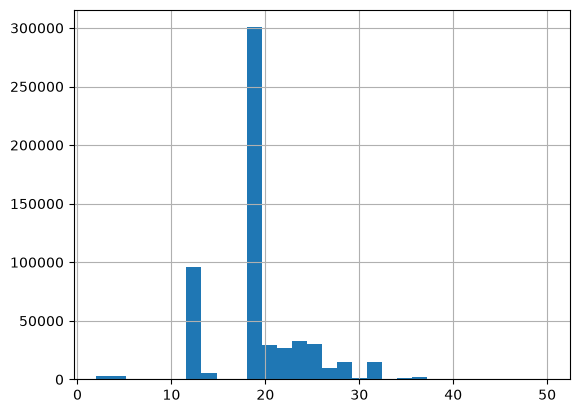

In [46]:
# Visualize the distribution of trace lengths.
# The plot is limited to traces with 50 or fewer events so the main distribution is easier to see.

trace_lengths[trace_lengths <= 50].hist(bins=30)

**Trace Length Observations**

Inspection of trace lengths revealed that most HDFS block traces contain a relatively small number of events.

The median trace length is 19 events, while 75% of all traces contain 20 events or fewer. Although the longest trace contains 298 events, the distribution shows that the vast majority of traces are concentrated within a much narrower range.

This suggests that HDFS block processing generally follows a consistent event sequence length, with a smaller number of unusually long traces representing more complex processing behavior.

Trace length may be useful as a potential feature during anomaly detection, but additional analysis is needed to determine whether longer or shorter traces are associated with anomalous behavior.

## ***Event Occurrence Matrix Dataset Overview***

The `Event_occurrence_matrix.csv` file contains a numerical representation of each HDFS block's event history. Instead of storing the chronological sequence of EventIds, this dataset records how many times each event template (E1 through E29) occurs during processing of an individual HDFS block.

This representation transforms the sequential log data into a fixed set of numerical features that are directly compatible with many traditional machine learning algorithms. Because each EventId corresponds to a known system operation (identified previously in `HDFS.log_templates.csv`), the occurrence matrix summarizes the frequency of those operations without preserving their order.

The following sections examine the structure of this dataset and determine how it differs from the event trace representation explored previously.

In [47]:
# Load the event occurrence matrix

matrix_df = pd.read_csv(
    dataset_path / "Event_occurrence_matrix.csv"
)

matrix_df.head()

,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
0,blk_-1608999687919862906,Success,NaN,0,0,203,0,10,7,0,0,3,0,3,0,0,0,0,4,0,4,0,0,10,1,10,0,4,10,0,0,0
1,blk_7503483334202473044,Success,NaN,0,2,1,0,3,0,0,0,3,0,3,0,0,0,0,0,0,0,0,0,3,1,3,0,0,3,0,0,0
2,blk_-3544583377289625738,Fail,21.0,0,0,203,0,3,0,0,0,3,0,3,0,0,0,0,0,0,0,0,1,3,1,3,0,0,3,0,0,0
3,blk_-9073992586687739851,Success,NaN,0,3,0,0,3,0,0,0,3,0,3,0,0,0,0,0,0,0,0,0,3,1,3,0,0,3,0,0,0
4,blk_7854771516489510256,Success,NaN,0,3,1,15,3,0,0,0,3,0,3,0,0,0,0,0,0,0,0,0,3,1,3,0,0,3,0,0,0


**Dataset Dimensions**

In [48]:
# Display dataset dimensions

print(f"Rows: {matrix_df.shape[0]:,}")
print(f"Columns: {matrix_df.shape[1]}")

Rows: 575,061
Columns: 32


**Dataset Shema**

In [49]:
# Display complete schema

pd.set_option("display.max_rows", None)
matrix_df.info()
pd.reset_option("display.max_rows")

<class 'pandas.DataFrame'>
RangeIndex: 575061 entries, 0 to 575060
Data columns (total 32 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   BlockId  575061 non-null  str    
 1   Label    575061 non-null  str    
 2   Type     16838 non-null   float64
 3   E1       575061 non-null  int64  
 4   E2       575061 non-null  int64  
 5   E3       575061 non-null  int64  
 6   E4       575061 non-null  int64  
 7   E5       575061 non-null  int64  
 8   E6       575061 non-null  int64  
 9   E7       575061 non-null  int64  
 10  E8       575061 non-null  int64  
 11  E9       575061 non-null  int64  
 12  E10      575061 non-null  int64  
 13  E11      575061 non-null  int64  
 14  E12      575061 non-null  int64  
 15  E13      575061 non-null  int64  
 16  E14      575061 non-null  int64  
 17  E15      575061 non-null  int64  
 18  E16      575061 non-null  int64  
 19  E17      575061 non-null  int64  
 20  E18      575061 non-null  int64  
 21

## Initial Observations

The `Event_occurrence_matrix.csv` dataset contains 575,061 records and 32 columns.

As with the previously explored datasets, each row represents the complete processing history of a single HDFS block. However, instead of storing the chronological sequence of events, this dataset summarizes the number of times each event template occurred during processing.

The first three columns provide identifying and labeling information:

- **BlockId** uniquely identifies each HDFS block.
- **Label** indicates whether the block completed successfully or experienced a failure.
- **Type** contains anomaly category information for failed blocks only, matching the pattern observed previously in the `Event_traces.csv` dataset.

The remaining 29 columns (E1 through E29) correspond directly to the event templates explored in `HDFS.log_templates.csv`. Each column records how many times a particular system event occurred while processing an individual HDFS block.

Unlike the Event Trace dataset, where event order is preserved, this representation summarizes event frequencies, producing a fixed-length numerical feature vector for every block.

**Block Identifier Verification**

Before examining the feature columns, the uniqueness of each HDFS block is verified. Since each row is expected to represent a single processed HDFS block, every BlockId should appear exactly once.

In [50]:
# Count unique Block IDs

print(f"Unique Block IDs: {matrix_df['BlockId'].nunique():,}")

Unique Block IDs: 575,061


The number of unique Block IDs matches the total number of records (575,061). This confirms that each HDFS block is represented by a single row within the occurrence matrix dataset.

**Missing Value Analysis**

The next step is to verify the completeness of each column. Particular attention is given to the Type field because it was previously observed to contain values only for anomalous blocks in the Event Trace dataset.

In [51]:
# Count missing values

matrix_df.isnull().sum()

BlockId         0
Label           0
Type       558223
E1              0
E2              0
E3              0
E4              0
E5              0
E6              0
E7              0
E8              0
E9              0
E10             0
E11             0
E12             0
E13             0
E14             0
E15             0
E16             0
E17             0
E18             0
E19             0
E20             0
E21             0
E22             0
E23             0
E24             0
E25             0
E26             0
E27             0
E28             0
E29             0
dtype: int64

In [52]:
# Verify which labels contain Type values

matrix_df.groupby("Label")["Type"].count()

Label
Fail       16838
Success        0
Name: Type, dtype: int64

The same pattern observed in the Event Trace dataset is confirmed here. The Type field is populated only for failed blocks and remains missing for successful blocks. Because this information directly identifies anomaly categories after a failure has occurred, it will be excluded from model development to prevent target leakage.

### **Event Occurrence Analysis**

Unlike the Event Trace dataset, which preserves the chronological order of system events, this dataset records how many times each event occurred during processing of an HDFS block.

The following analysis verifies that each EventId is represented by its own numerical feature column and begins examining the distribution of those event counts.

In [53]:
# Confirm event feature data types

matrix_df.iloc[:, 3:].dtypes

E1     int64
E2     int64
E3     int64
E4     int64
E5     int64
E6     int64
E7     int64
E8     int64
E9     int64
E10    int64
E11    int64
E12    int64
E13    int64
E14    int64
E15    int64
E16    int64
E17    int64
E18    int64
E19    int64
E20    int64
E21    int64
E22    int64
E23    int64
E24    int64
E25    int64
E26    int64
E27    int64
E28    int64
E29    int64
dtype: object

Although each event (E1 through E29) occupies its own column, the meaning of the numerical values within those columns is not yet clear. At this stage, it cannot be assumed that the values represent event frequencies, weights, identifiers, or another encoded measurement. To investigate this, the unique values observed for each event column were examined to determine whether the values remain constant or vary across HDFS block traces.

In [54]:
# Number of unique occurrence values for each event

matrix_df.iloc[:, 3:].nunique()

E1      2
E2      5
E3     12
E4     23
E5     13
E6     11
E7      5
E8      3
E9      4
E10     4
E11     7
E12     3
E13     2
E14     5
E15     3
E16     6
E17     2
E18     6
E19     3
E20     4
E21    14
E22     1
E23     8
E24     2
E25     6
E26    12
E27     3
E28     5
E29     3
dtype: int64

The results show that the values differ within each event column. Rather than containing a single fixed value, most event columns contain multiple unique values across the dataset. This confirms that the numerical entries carry additional information beyond simply indicating whether an event occurred. However, the exact meaning of these values cannot be determined from the dataset structure alone and will require further investigation through the original dataset documentation or additional analysis.

#### **Comparing Event Traces to the Occurrence Matrix**

To better understand the numerical values stored in the event occurrence matrix, the same HDFS block will be examined in both the Event_traces.csv and Event_occurrence_matrix.csv datasets.

The goal of this comparison is to determine whether the values stored in the E1 through E29 columns correspond to characteristics of the original event sequence recorded for each HDFS block.

Two blocks will be examined. The first is a representative block whose trace length is equal to the dataset median, and the second is the longest trace in the dataset. Comparing both examples helps determine whether the relationship between the trace dataset and the occurrence matrix remains consistent across different trace lengths.

In [56]:
# Select a representative block with the median trace length
median_length = int(trace_lengths.median())

sample_index = trace_lengths[trace_lengths == median_length].index[0]

sample_block = traces_df.loc[sample_index, "BlockId"]

print(f"Representative Block ID: {sample_block}")
print(f"Trace Length: {median_length} events")

Representative Block ID: blk_-4898747391262002624
Trace Length: 19 events


In [57]:
# Display the original event sequence
traces_df.loc[
    traces_df["BlockId"] == sample_block,
    ["BlockId", "Features"]
]

,BlockId,Features
29530,blk_-4898747391262002624,"[E5,E5,E5,E22,E11,E9,E11,E9,E11,E9,E26,E26,E26..."


In [58]:
# Display the corresponding occurrence matrix row
matrix_df.loc[
    matrix_df["BlockId"] == sample_block
]

,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
29530,blk_-4898747391262002624,Success,NaN,0,0,0,0,3,0,0,0,3,0,3,0,0,0,0,0,0,0,0,0,3,1,3,0,0,3,0,0,0


In [72]:
from collections import Counter

# Count EventIds appearing in the trace
events = (
    traces_df.loc[
        traces_df["BlockId"] == sample_block,
        "Features"
    ]
    .iloc[0]
    .strip("[]")
    .split(",")
)

event_counts = Counter(events)

pd.Series(
    dict(sorted(event_counts.items(), key=lambda x: int(x[0][1:])))
)

E5     3
E9     3
E11    3
E21    3
E22    1
E23    3
E26    3
dtype: int64

In [60]:
# Display only nonzero event values from the occurrence matrix
matrix_row = (
    matrix_df.loc[
        matrix_df["BlockId"] == sample_block
    ]
    .iloc[0]
)

matrix_row.loc["E1":"E29"][
    matrix_row.loc["E1":"E29"] > 0
]

E5     3
E9     3
E11    3
E21    3
E22    1
E23    3
E26    3
Name: 29530, dtype: object

In [61]:
# Select the longest trace in the dataset
longest_index = trace_lengths.idxmax()

longest_block = traces_df.loc[longest_index, "BlockId"]

print(f"Longest Block ID: {longest_block}")
print(f"Trace Length: {trace_lengths.max()} events")

Longest Block ID: blk_-4145674605155741075
Trace Length: 298 events


In [62]:
# Display the original event sequence
traces_df.loc[
    traces_df["BlockId"] == longest_block,
    ["BlockId", "Features"]
]

,BlockId,Features
286063,blk_-4145674605155741075,"[E5,E22,E5,E5,E11,E9,E26,E11,E9,E11,E9,E25,E26..."


In [63]:
# Display the corresponding occurrence matrix row
matrix_df.loc[
    matrix_df["BlockId"] == longest_block
]

,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
286063,blk_-4145674605155741075,Success,NaN,0,0,203,18,12,9,0,0,3,0,3,0,0,0,0,5,0,5,0,0,12,1,10,0,5,12,0,0,0


In [68]:
# Count EventIds appearing in the trace
events = (
    traces_df.loc[
        traces_df["BlockId"] == longest_block,
        "Features"
    ]
    .iloc[0]
    .strip("[]")
    .split(",")
)

event_counts = Counter(events)

dict(sorted(event_counts.items(), key=lambda x: int(x[0][1:])))

{'E3': 203,
 'E4': 18,
 'E5': 12,
 'E6': 9,
 'E9': 3,
 'E11': 3,
 'E16': 5,
 'E18': 5,
 'E21': 12,
 'E22': 1,
 'E23': 10,
 'E25': 5,
 'E26': 12}

In [67]:
# Display only nonzero event values from the occurrence matrix
matrix_row = (
    matrix_df.loc[
        matrix_df["BlockId"] == longest_block
    ]
    .iloc[0]
)

matrix_row.loc["E1":"E29"][
    matrix_row.loc["E1":"E29"] > 0
]

E3     203
E4      18
E5      12
E6       9
E9       3
E11      3
E16      5
E18      5
E21     12
E22      1
E23     10
E25      5
E26     12
Name: 286063, dtype: object

#### **Comparison Results**

The comparison confirmed that the event occurrence matrix is a direct numerical representation of the original event traces.

For both the representative block and the longest block, the frequency of every EventId in the original trace matched the corresponding value stored in the occurrence matrix. This verification demonstrates that each E1 through E29 column records the number of times its associated system event occurred while processing an HDFS block.

The consistency observed across both examples provides confidence that the occurrence matrix was generated directly from the event traces and accurately preserves event frequency information. This also validates that the numerical feature vectors used for model development faithfully represent the original system log data.

Having confirmed this relationship, the occurrence matrix can now be used with confidence as the primary feature set for the traditional machine learning models evaluated later in this study.

# ***Conclusions and Next Steps***

This exploratory analysis provided a comprehensive understanding of the primary datasets that describe HDFS block processing from multiple perspectives and established the foundation for the experimental phase of this research.

The **anomaly_label.csv** dataset established the ground-truth classifications that will be used to train and evaluate the supervised machine learning models. The **HDFS.log_templates.csv** dataset provided semantic meaning for each EventId, allowing the numerical event identifiers to be interpreted as specific HDFS system operations.

The **Event_traces.csv** dataset preserved the complete chronological sequence of system events associated with each HDFS block. Analysis of the traces revealed both typical processing patterns and substantial variation in trace lengths across the dataset.

The **Event_occurrence_matrix.csv** dataset was verified to be a numerical representation of the event traces. By comparing multiple HDFS blocks across both datasets, it was confirmed that each EventId column (E1 through E29) records the number of times that event occurred within the corresponding trace. This validation confirmed that the occurrence matrix accurately preserves event frequency information while representing every HDFS block as a fixed-length numerical feature vector.

Several important findings emerged during the exploratory analysis:

- Each BlockId uniquely represents a single HDFS block across all datasets.
- The **Type** column contains anomaly-specific information and will be excluded from model development to prevent target leakage.
- The event occurrence matrix provides a consistent numerical feature representation suitable for traditional machine learning algorithms.
- The event trace dataset preserves the chronological ordering of system events, while the occurrence matrix retains only event frequencies.

Based on these findings, the **Event_occurrence_matrix.csv** dataset currently appears to be the most appropriate feature set for the planned statistical baseline, Logistic Regression, Random Forest, and Isolation Forest experiments because these methods operate on structured numerical feature vectors.

One important question emerged during the exploratory analysis. While the occurrence matrix preserves how frequently each event occurs, it does not preserve the order in which events occurred. It remains possible that the sequence of events itself contains meaningful patterns that distinguish normal system behavior from anomalous behavior. If so, relying solely on event frequencies may omit valuable predictive information.

At this stage, the occurrence matrix will remain the planned feature representation for model development. However, the potential value of incorporating event sequence information through additional feature engineering or alternative modeling approaches will be discussed before finalizing the experimental pipeline.

The next phase of this research will focus on preparing the modeling dataset, performing the 80/20 training and testing split, developing the statistical rule-based baseline using the training data, and implementing the supervised and unsupervised machine learning models for comparison.